# DeFiPy: Python SDK for DeFi Analytics
## Chapter 4: Simulating Trades with DeFiPy

### Listing 4.1: Setup a Uniswap V2 Liquidity Pool

In [1]:
from defipy import ERC20, UniswapFactory, UniswapExchangeData

# Define tokens
eth  = ERC20("ETH",  "0xE...ETH")
usdc = ERC20("USDC","0xA...USDC")

# Create V2 exchange data
v2_data = UniswapExchangeData(
    tkn0=eth,
    tkn1=usdc,
    symbol="UNI-V2-ETH-USDC",
    address="0xPOOLADDRV2",
    version="V2"
)

# Deploy via factory
factory = UniswapFactory("Uniswap V2 Factory", address="0xFACTORYV2")
v2_pool = factory.deploy(v2_data)

### Listing 4.2: Setup a Uniswap V3 Liquidity Pool

In [2]:
from defipy import UniswapFactory, UniswapExchangeData

# Reuse eth, usdc definitions

# Create V3 exchange data
v3_data = UniswapExchangeData(
    tkn0=eth,
    tkn1=usdc,
    symbol="UNI-V3-ETH-USDC",
    address="0xPOOLADDRV3",
    version="V3",
    fee=3000,         # 0.3% fee tier
    tick_spacing=60   # granularity for 0.3% tier
)

# Deploy via the same factory
v3_pool = factory.deploy(v3_data)

### Listing 4.3: Setup a Balancer Liquidity Pool

In [3]:
from defipy import BalancerVault, BalancerFactory, BalancerExchangeData, ERC20

# Define tokens
dai = ERC20("DAI", "0xB...DAI")
eth = ERC20("ETH", "0xE...ETH")

# Configure vault
vault = BalancerVault()
vault.add_token(dai, weight=10)  # 20% weight
vault.add_token(eth, weight=40)  # 80% weight

# Create exchange data
bal_data = BalancerExchangeData(
    vault=vault,
    symbol="B-ETH-DAI-80-20",
    address="0xPOOLADDRBAL"
)

# Deploy via factory
b_factory = BalancerFactory("Balancer Factory", address="0xFACTORYBAL")
bal_lp = b_factory.deploy(bal_data)

### Listing 4.4: Setup a Stableswap Liquidity Pool

In [4]:
from defipy import StableswapVault, StableswapFactory, StableswapExchangeData, ERC20

# Define stablecoins
usdc = ERC20("USDC", "0xA...USDC", decimal=6)
dai  = ERC20("DAI",  "0xB...DAI",  decimal=18)

# Configure vault
s_vault = StableswapVault()
s_vault.add_token(usdc)
s_vault.add_token(dai)

# Create exchange data
ss_data = StableswapExchangeData(
    vault=s_vault,
    symbol="SS-DAI-USDC",
    address="0xPOOLADDRSS"
)

# Deploy via factory
ss_factory = StableswapFactory("StableSwap Factory", address="0xFACTORYSS")
ss_lp = ss_factory.deploy(ss_data)

### Listing 4.5: Simulating a trade on Uniswap V2

In [23]:
from defipy import ERC20, UniswapFactory, UniswapExchangeData, Join, Swap

# Step 1: Create tokens
token_a = ERC20("TokenA", "0x111")
token_b = ERC20("TokenB", "0x999")

# Step 2: Deploy exchange
factory = UniswapFactory("ETH pool factory", "0x2")
exch_data = UniswapExchangeData(tkn0=token_a, tkn1=token_b, symbol="LP", address="0x3")
lp = factory.deploy(exch_data)

# Step 3: Add initial liquidity
join = Join()
join.apply(lp, "user", 1000, 1000)

# Step 4: Simulate trade
swap = Swap()
amount_out = swap.apply(lp, token_a, "trader", 10)

lp.summary()
print(f"Received {amount_out:.4f} of {token_b.token_name}")

Exchange TokenA-TokenB (LP)
Reserves: TokenA = 1010.0, TokenB = 990.1284196560293
Liquidity: 1000.0 

Received 9.8716 of TokenB


### Listing 4.6: Simulating a trade on Uniswap V3

In [39]:
from defipy import ERC20, UniswapFactory, Join, Swap, UniV3Helper

# Step 1: Create tokens
token_a = ERC20("TokenA", "0x111")
token_b = ERC20("TokenB", "0x999")

# Step 2: Deploy pool with 0.3% fee tier
exch_data = UniswapExchangeData(tkn0=token_a, tkn1=token_b, symbol="LP", address="0x811", version='V3', tick_spacing=60, fee=3000)
factory = UniswapFactory("ETH pool factory", "0x2")
lp = factory.deploy(exch_data)

# Step 3: Custom price ticks around initial price
init_price = 1
lwr_tick = UniV3Helper().get_price_tick(lp, -1, init_price, 1000)
upr_tick = UniV3Helper().get_price_tick(lp, 1, init_price, 1000)

# Step 4: Add liquidity within tick range 
join = Join()
join.apply(lp, "user", 1000, 1000, lwr_tick, upr_tick)

# Step 5: Simulate trade with price limit
swap = Swap()
amount_out = swap.apply(lp, token_a, "trader", 10)

lp.summary()
print(f"Received {amount_out:.4} of {token_b.token_name}")

Exchange TokenA-TokenB (LP)
Real Reserves:   TokenA = 1009.9999999999991, TokenB = 990.0349396554689
Gross Liquidity: 20113.073116388397 

Received 9.965 of TokenB


### Listing 4.7: Simulating a trade on Balancer

In [111]:
from defipy import ERC20, Proc, BalancerFactory, Join, Swap

# Step 1: Create tokens
token_a = ERC20("TokenA", "0x111")
token_b = ERC20("TokenB", "0x999")
token_c = ERC20("TokenC", "0x555")

# Step 2: Deposit token amounts
token_a.deposit(None, 1000)
token_b.deposit(None, 1000)

# Step 3: Setup vault
vault = BalancerVault()
vault.add_token(token_a, 50)  # Denormalized weight for token_a
vault.add_token(token_b, 50)  # Denormalized weight for token_b

# Step 4: Set up exchange data for Balancer
exch_data = BalancerExchangeData(vault=vault, symbol="BSP", address="0x3")

# Step 5: Deploy exchange with weights [0.5, 0.3, 0.2]
bfactory = BalancerFactory("WETH pool factory", "0x2")
lp = bfactory.deploy(exch_data)

# Step 6: Add liquidity (optional)
join = Join()
join.apply(lp, "user", 100)

# Step 7: Simulate trade from TokenA to TokenB
swap = Swap(Proc.SWAPOUT)
amount_out = swap.apply(lp, token_a, token_b, "trader", 10)

lp.summary()
print(f"Received {amount_out['tkn_out_amt']:.4} of TokenB")

Balancer Exchange: TokenA-TokenB (BSP)
Reserves: TokenA = 1010, TokenB = 990.1235179088592
Weights: TokenA = 0.5, TokenB = 0.5
Pool Shares: 100 

Received 9.876 of TokenB


### Listing 4.8: Simulating a trade on Stableswap

In [134]:
from defipy import ERC20, StableswapVault, StableswapFactory, StableswapExchangeData, Join, Swap

# Step 1: Create tokens
token_a = ERC20("TokenA", "0x111", 18)
token_b = ERC20("TokenB", "0x222", 6)
AMPL_COEFF = 2000

# Step 2: Deposit token amounts
token_a.deposit(None, 1000)
token_b.deposit(None, 1000)

# Step 3: Setup Stableswap vault and add tokens
sgrp = StableswapVault()
sgrp.add_token(token_a)
sgrp.add_token(token_b)

# Step 4: Set up exchange data for Stableswap
exch_data = StableswapExchangeData(vault = sgrp, symbol="LP", address="0x011")

# Step 5: Initialize factor for Balancer
factory = StableswapFactory("Stableswap factory", "0x2")

# Step 6: Deploy pool
lp = factory.deploy(exch_data)

# Step 7: Add liquidity (optional)
join = Join()
join.apply(lp, "user", AMPL_COEFF)

# Step 8: Simulate trade from USDC to DAI
swap = Swap()
amount_out = swap.apply(lp, token_a, token_b, "trader", 100)

lp.summary()
print(f"Received {amount_out['tkn_out_amt']:.6} of {token_b.token_name}")

Stableswap Exchange: TokenA-TokenB (LP)
Reserves: TokenA = 1100, TokenB = 900.015048
Liquidity: 2000.0 

Received 99.985 of TokenB


### Listing 4.9: Computing slippage and price impact in Uniswap V2

In [138]:
from defipy import ERC20, UniswapFactory, UniswapExchangeData, Join, Swap

# Step 1: Create tokens
token_a = ERC20("TokenA", "0x111")
token_b = ERC20("TokenB", "0x999")

# Step 2: Deploy exchange
factory = UniswapFactory("ETH pool factory", "0x2")
exch_data = UniswapExchangeData(tkn0=token_a, tkn1=token_b, symbol="LP", address="0x3")
lp = factory.deploy(exch_data)

# Step 5: Add initial liquidity
join = Join()
join.apply(lp, "user", 1000, 1000)

# Step 3: Initial price
p_initial = lp.get_price(token_a)  # token_a per token_b

# Step 4: Initialize Uniswap V2 pool
swap = Swap()
delta_x = 10
delta_y = swap.apply(lp, token_a, "trader", delta_x)

# Step 5: Compute slippage
expected_y = p_initial * delta_x
slippage = (1 - delta_y / expected_y) * 100
print(f"Slippage: {slippage:.4f}%")

# Step 6: Compute price impact
p_final = lp.get_price(token_a)
price_impact = ((p_final - p_initial) / p_initial) * 100
print(f"Price Impact: {price_impact:.4f}%")

Slippage: 1.2842%
Price Impact: -1.9675%


### Listing 4.10: Computing slippage and price impact in Uniswap V3

In [141]:
from defipy import ERC20, UniswapFactory, Join, Swap, UniV3Helper

# Step 1: Create tokens
token_a = ERC20("TokenA", "0x111")
token_b = ERC20("TokenB", "0x999")

# Step 2: Deploy pool with 0.3% fee tier
exch_data = UniswapExchangeData(tkn0=token_a, tkn1=token_b, symbol="LP", address="0x811", version='V3', tick_spacing=60, fee=3000)
factory = UniswapFactory("ETH pool factory", "0x2")
lp = factory.deploy(exch_data)

# Step 3: Custom price ticks around initial price
init_price = 1
lwr_tick = UniV3Helper().get_price_tick(lp, -1, init_price, 1000)
upr_tick = UniV3Helper().get_price_tick(lp, 1, init_price, 1000)

# Step 4: Add liquidity within tick range 
join = Join()
join.apply(lp, "user", 1000, 1000, lwr_tick, upr_tick)

# Step 5: Initial price
p_initial = lp.get_price(token_a)

# Step 6: Simulate trade with price limit
swap = Swap()
delta_x = 10
delta_y = swap.apply(lp, token_a, "trader", delta_x)

# Step 7: Compute slippage
expected_y = p_initial * delta_x
slippage = (1 - delta_y / expected_y) * 100
print(f"Slippage: {slippage:.4f}%")

# Step 8: Compute price impact
p_final = lp.get_price(token_a)
price_impact = ((p_final - p_initial) / p_initial) * 100
print(f"Price Impact: {price_impact:.4f}%")

Slippage: 0.3494%
Price Impact: -0.0991%


### Listing 4.11: Computing slippage and price impact in Balancer

In [143]:
from defipy import ERC20, Proc, BalancerFactory, Join, Swap

# Step 1: Create tokens
token_a = ERC20("TokenA", "0x111")
token_b = ERC20("TokenB", "0x999")
token_c = ERC20("TokenC", "0x555")

# Step 2: Deposit token amounts
token_a.deposit(None, 1000)
token_b.deposit(None, 1000)

# Step 3: Setup vault
vault = BalancerVault()
vault.add_token(token_a, 50)  # Denormalized weight for token_a
vault.add_token(token_b, 50)  # Denormalized weight for token_b

# Step 4: Set up exchange data for Balancer
exch_data = BalancerExchangeData(vault=vault, symbol="BSP", address="0x3")

# Step 5: Deploy exchange with weights [0.5, 0.3, 0.2]
bfactory = BalancerFactory("WETH pool factory", "0x2")
lp = bfactory.deploy(exch_data)

# Step 6: Add liquidity (optional)
join = Join()
join.apply(lp, "user", 100)

# Step 7: Initial price
p_initial = lp.get_price(token_a, token_b)

# Step 8: Simulate trade from TokenA to TokenB
swap = Swap(Proc.SWAPIN)
delta_x = 10
amount_out = swap.apply(lp, token_a, token_b, "trader", delta_x)
delta_y = amount_out['tkn_in_amt']

# Step 9: Compute slippage
expected_y = p_initial * delta_x
slippage = (1 - delta_y / expected_y) * 100
print(f"Slippage: {slippage:.4f}%")

# Step 10: Compute price impact
p_final = lp.get_price(token_a, token_b)
price_impact = ((p_final - p_initial) / p_initial) * 100
print(f"Price Impact: {price_impact:.4f}%")

Slippage: -1.0101%
Price Impact: -1.9927%


### Listing 4.12: Computing slippage and price impact in Stableswap

In [145]:
from defipy import ERC20, StableswapVault, StableswapFactory, StableswapExchangeData, Join, Swap

# Step 1: Create tokens
token_a = ERC20("TokenA", "0x111", 18)
token_b = ERC20("TokenB", "0x222", 6)
AMPL_COEFF = 2000

# Step 2: Deposit token amounts
token_a.deposit(None, 1000)
token_b.deposit(None, 1000)

# Step 3: Setup Stableswap vault and add tokens
sgrp = StableswapVault()
sgrp.add_token(token_a)
sgrp.add_token(token_b)

# Step 4: Set up exchange data for Stableswap
exch_data = StableswapExchangeData(vault = sgrp, symbol="LP", address="0x011")

# Step 5: Initialize factor for Balancer
factory = StableswapFactory("Stableswap factory", "0x2")

# Step 6: Deploy pool
lp = factory.deploy(exch_data)

# Step 6: Add liquidity (optional)
join = Join()
join.apply(lp, "user", AMPL_COEFF)

# Step 7: Swap
swap = Swap()
delta_x = 10
amount_out = swap.apply(lp, token_a, token_b, "trader", delta_x)
delta_y = amount_out['tkn_out_amt']

# Step 8: Compute slippage
expected_y = p_initial * delta_x
slippage = (1 - delta_y / expected_y) * 100
print(f"Slippage: {slippage:.4f}%")

# Step 9: Compute price impact
p_final = lp.get_price(token_a, token_a)
price_impact = ((p_final - p_initial) / p_initial) * 100
print(f"Price Impact: {price_impact:.4f}%")

Slippage: 0.2605%
Price Impact: -0.2500%


### Listing 4.13: Setup Price Curve Swap

In [165]:
import matplotlib.pyplot as plt
from defipy import EventSelectionModel, TokenDeltaModel

user_nm = 'swap_plot'
tkn1_amount = 5
tkn2_amount = 30

tkn1 = ERC20("TKN1", "0x111")
tkn2 = ERC20("TKN2", "0x09")
exchg_data = UniswapExchangeData(tkn0 = tkn1, tkn1 = tkn2, symbol="LP", address="0x011")

factory = UniswapFactory("ETH pool factory", "0x2")
lp = factory.deploy(exchg_data)
Join().apply(lp, user_nm, tkn1_amount, tkn2_amount)
lp.summary()

n_events = 5
pos = []

for k in range(n_events):
    
    select_tkn = EventSelectionModel().bi_select(0.5)
    if(select_tkn == 0):
        dy = TokenDeltaModel(lp.get_reserve(tkn2)).delta()
        out = Swap().apply(lp, tkn2, user_nm, dy)
    else:
        dy = TokenDeltaModel(lp.get_reserve(tkn1)).delta()
        out = Swap().apply(lp, tkn1, user_nm, dy)

    pos.append([lp.get_reserve(tkn1),
                lp.get_reserve(tkn2),
                lp.get_liquidity()])

Exchange TKN1-TKN2 (LP)
Reserves: TKN1 = 5.0, TKN2 = 30.0
Liquidity: 12.24744871391589 



### Listing 4.14: Price Curve Swaps

(0.0, 66.82239334981725)

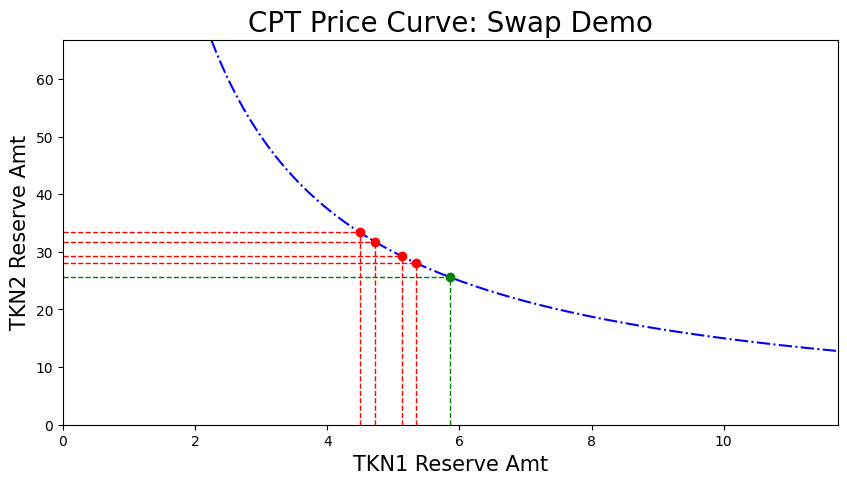

In [166]:
import numpy as np

x_max = 2*max([row[0] for row in pos]); 
x_min = 0.5*min([row[0] for row in pos])
y_max = 2*max([row[1] for row in pos])

L = pos[0][2]
x_arr = np.arange(x_min, x_max, 0.01)
y_arr = L**2/x_arr

fig, (ax) = plt.subplots(nrows=1, sharex=False, sharey=False, figsize=(10, 5))
ax.plot(x_arr, y_arr, color = 'b',linestyle = 'dashdot', label='initial invest')

for k in range(n_events):
    x = pos[k][0]; y = pos[k][1]
    coord_col = 'g' if k == 0 else 'r'
    ax.hlines(y = y, xmin=0, xmax=x, linewidth=1, color=coord_col, linestyle = 'dashed')
    ax.vlines(x = x, ymin=0, ymax=y, linewidth=1, color=coord_col, linestyle = 'dashed')
    ax.plot(x, y, 'ro', color= coord_col)

ax.set_title(f'CPT Price Curve: Swap Demo', fontsize=20)
ax.set_ylabel(f'{tkn2.token_name} Reserve Amt', size=15)
ax.set_xlabel(f'{tkn1.token_name} Reserve Amt', size=15)
ax.set_xlim((0,x_max))
ax.set_ylim((0,y_max))

### Listing 4.15: Setup Price Curve Liquidity

In [169]:
from defipy import RemoveLiquidity, AddLiquidity

user_nm = 'liq_plot'
tkn1_amount = 5
tkn2_amount = 30

tkn1 = ERC20("TKN1", "0x111")
tkn2 = ERC20("TKN2", "0x09")
exchg_data = UniswapExchangeData(tkn0 = tkn1, tkn1 = tkn2, symbol="LP", address="0x011")

factory = UniswapFactory("ETH pool factory", "0x2")
lp = factory.deploy(exchg_data)
Join().apply(lp, user_nm, tkn1_amount, tkn2_amount)
lp.summary()

n_events = 5
pos = []

for k in range(n_events):
    
    select_tkn = EventSelectionModel().bi_select(0.5)
    if(select_tkn == 0):
        dy = TokenDeltaModel(lp.get_reserve(tkn2)).delta()
        out = AddLiquidity().apply(lp, tkn2, user_nm, dy)
    else:
        dy = TokenDeltaModel(lp.get_reserve(tkn1)).delta()
        out = RemoveLiquidity().apply(lp, tkn1, user_nm, dy)

    pos.append([lp.get_reserve(tkn1),
                lp.get_reserve(tkn2),
                lp.get_liquidity()])

Exchange TKN1-TKN2 (LP)
Reserves: TKN1 = 5.0, TKN2 = 30.0
Liquidity: 12.24744871391589 



### Listing 4.16: Price Curves

(0.0, 98.71671081312323)

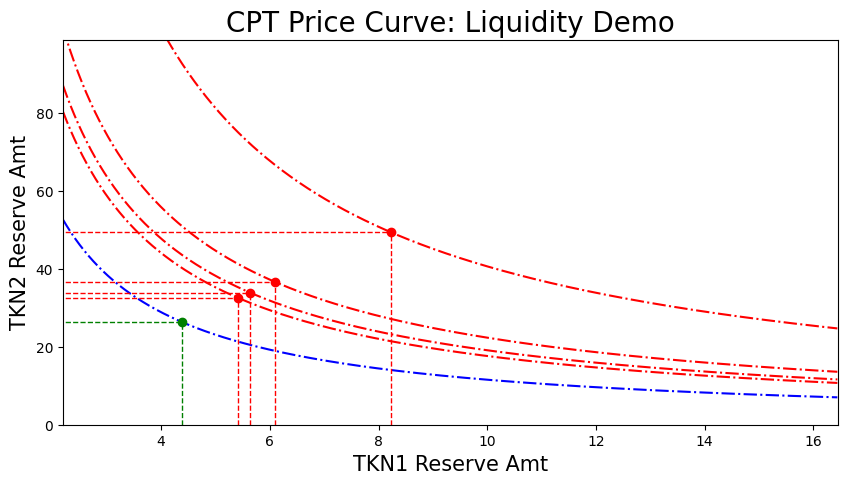

In [170]:
x_max = 2*max([row[0] for row in pos]); 
x_min = 0.5*min([row[0] for row in pos])
y_max = 2*max([row[1] for row in pos])

fig, (ax) = plt.subplots(nrows=1, sharex=False, sharey=False, figsize=(10, 5))

for k in range(n_events):

    L = pos[k][2]
    x_arr = np.arange(x_min, x_max, 0.01)
    y_arr = L**2/x_arr
    coord_col = 'b' if k == 0 else 'r'
    ax.plot(x_arr, y_arr, color = coord_col, linestyle = 'dashdot', label='initial invest')
    
    x = pos[k][0]; y = pos[k][1]
    coord_col = 'g' if k == 0 else 'r'
    ax.hlines(y = y, xmin=0, xmax=x, linewidth=1, color=coord_col, linestyle = 'dashed')
    ax.vlines(x = x, ymin=0, ymax=y, linewidth=1, color=coord_col, linestyle = 'dashed')
    ax.plot(x, y, 'ro', color= coord_col)

ax.set_title(f'CPT Price Curve: Liquidity Demo', fontsize=20)
ax.set_ylabel(f'{tkn2.token_name} Reserve Amt', size=15)
ax.set_xlabel(f'{tkn1.token_name} Reserve Amt', size=15)
ax.set_xlim((x_min,x_max))
ax.set_ylim((0,y_max))